# Linear Regression 1
The `LinearRegression` estimator is usd to find equation of line:
$$
y = a_0 + a_1 x_1 + a_2 x_2 + \cdots
$$
where there are multiple $x$ values.
Geometrically, this is akin to fitting a plane to points in three dimensions, or fitting a hyperplane to points in higher dimensions.
Here $x_1$ , $x_2$, etc are features. Here **y is dependant variable, and x1,x2,etc are indep var.**

**NOTE: In medical domain, this could be relation between Systolic BP(y), BMI(x1), PTT(x2)**

**QUESTION:** If you had studied longer, would your overall scores get any better?

One way of answering this question is by having data on how long you studied for and what scores you got. We can then try to see if there is a pattern in that data, and if in that pattern, when you add to the hours, it also ends up adding to the scores percentage.

For instance, say you have an hour-score dataset, which contains entries such as 1.5h and 87.5% score. It could also contain 1.61h, 2.32h and 78%, 97% scores, respectively. The kind of data type that can have any intermediate value (or any level of 'granularity') is known as continuous data

Here we are trying to find equation of line, 
$$
y = a_0 + a_1 x_1 
$$

that can describe relation between $x_1$ (hours) and y (scores). $a_0$ is the intercept/bias and $a_1$ is the $x_1$-coefficient or the weight of $x_1$.

Regression is performed on continuous data
- Here I manually added duplicate value and some null values

In [1]:
import pandas as pd
import numpy as np

# Lets import some visual lib.
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\hi\AppData\Local\Temp\ipykernel_10712\2242451289.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# 1. Data collection
Lets load the dataset

In [2]:
df = pd.read_csv('student_scores.csv')
# df = pd.read_csv('/content/sample_data/student_scores.csv') # use this when uploading the CSV file to colab

# Use following when running directly from github. The raw URL is obtained by clicking on the raw button.
# df = pd.read_csv('https://raw.githubusercontent.com/ash322ash422/tut_ml/refs/heads/master/tut_linear_regression/student_scores.csv')

print(df)

    Hours  Scores
0     2.5    21.0
1     5.1    47.0
2     3.2    27.0
3     8.5    75.0
4     3.5    30.0
5     1.5    20.0
6     9.2    88.0
7     5.5    60.0
8     8.3    81.0
9     2.7    25.0
10    7.7    85.0
11    5.9    62.0
12    4.5    41.0
13    3.3    42.0
14    1.1    17.0
15    8.9    95.0
16    2.5    30.0
17    1.9    24.0
18    6.1    67.0
19    7.4    69.0
20   15.0    80.0
21    2.7    30.0
22    4.8    54.0
23    3.8    35.0
24    6.9    76.0
25    7.8    86.0
26    7.8     NaN
27    3.8     NaN
28    7.9     NaN
29    NaN    86.0
30    NaN    45.0
31    NaN    34.0
32    NaN    56.0
33    NaN    32.0
34    NaN    55.0
35    NaN    33.0
36    7.8    86.0


In [3]:
# Lets look at column
print(df['Hours']) 

0      2.5
1      5.1
2      3.2
3      8.5
4      3.5
5      1.5
6      9.2
7      5.5
8      8.3
9      2.7
10     7.7
11     5.9
12     4.5
13     3.3
14     1.1
15     8.9
16     2.5
17     1.9
18     6.1
19     7.4
20    15.0
21     2.7
22     4.8
23     3.8
24     6.9
25     7.8
26     7.8
27     3.8
28     7.9
29     NaN
30     NaN
31     NaN
32     NaN
33     NaN
34     NaN
35     NaN
36     7.8
Name: Hours, dtype: float64


# 2. Data labelling
Data is already labeled


# 3. Exploratory Data Analysis (EDA)
You want to get to know your data first - this includes visualizing features, exploring their relationships and making hypotheses based on your observations. The dataset is a CSV (comma-separated values) file, which contains the hours studied and the scores obtained based on those hours

In [4]:
print(df.head(5)) # prints the first 5 records

   Hours  Scores
0    2.5    21.0
1    5.1    47.0
2    3.2    27.0
3    8.5    75.0
4    3.5    30.0


In [5]:
print(df.tail(4)) # prints the last 4 records

    Hours  Scores
33    NaN    32.0
34    NaN    55.0
35    NaN    33.0
36    7.8    86.0


In [6]:
print(df.shape) # display (rows,columns)

(37, 2)


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   30 non-null     float64
 1   Scores  34 non-null     float64
dtypes: float64(2)
memory usage: 720.0 bytes
None


### observation
- There are total of 36 entries
- Hours has 29 non-null entries
- Scores has 33 non-null entries 

In [8]:
print(df.describe())

           Hours     Scores
count  30.000000  34.000000
mean    5.586667  52.764706
std     3.041294  24.363483
min     1.100000  17.000000
25%     3.225000  30.500000
50%     5.300000  50.500000
75%     7.800000  75.750000
max    15.000000  95.000000


### Lets visualize
Our initial question was whether we'd score a higher score if we'd studied longer. In essence, we're asking for the relationship between Hours and Scores. So, what's the relationship between these variables? A great way to explore relationships between variables is through Scatter plots. We'll plot the hours on the X-axis and scores on the Y-axis, and for each pair, a marker will be positioned based on their values:

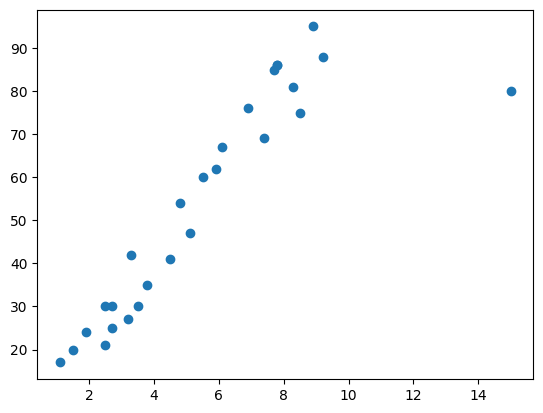

In [9]:
# Lets plot scatter graph between x1 and y variable
plt.scatter( x=df['Hours'], y=df['Scores'])
# plt.title('Scatterplot of hours and scores percentages')
plt.show() 

# df.plot.scatter(x='Hours', y='Scores', title='Scatterplot of hours and scores percentages')

# Observ: There is a linear relation between x and y

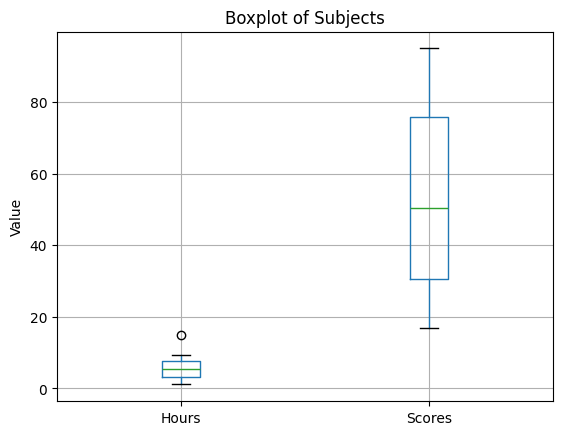

In [10]:
# Boxplot (STYLE1: DO NOT USE THIS because the range of values in Hours and Scores differs by wide margin): There are outliers 

df.boxplot()  # or df.plot(kind='box')

plt.title("Boxplot of Subjects")
plt.ylabel("Value")
plt.grid(True)

plt.show()

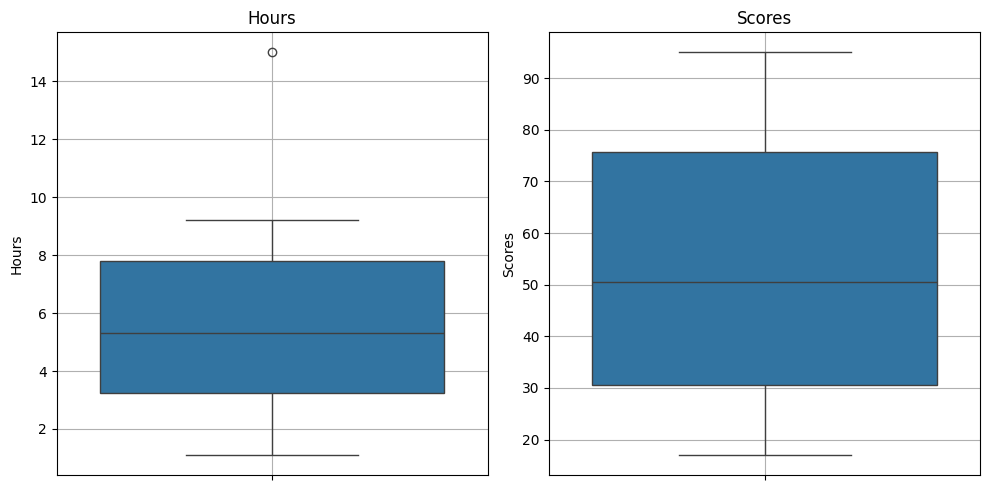

In [11]:
# Boxplot (STYLE2): There are outliers 

# Create a figure with 2 subplots in 1 row
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Boxplot for Hours
sns.boxplot(y=df['Hours'], ax=axes[0])
axes[0].set_title('Hours')
axes[0].grid(True)

# Boxplot for Scores
sns.boxplot(y=df['Scores'], ax=axes[1])
axes[1].set_title('Scores')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Boxplot shows:
# Minimum (excluding outliers): The smallest data point still within 1.5 IQR of the lower quartile.
# First Quartile (Q1): 25% of the data fall below this value.
# Median (Q2): The middle value (50% of the data fall below this).
# Third Quartile (Q3): 75% of the data fall below this value.
# Maximum (excluding outliers): The largest data point still within 1.5 IQR of the upper quartile.

# Box Components:
# Box: Spans from Q1 to Q3 (the interquartile range, or IQR). It shows the middle 50% of the data.
# Line inside the box: The median.
# Whiskers: Extend from the box to the minimum and maximum values within 1.5 * IQR from Q1 and Q3.
# Dots (Outliers): Individual points that fall outside the whiskers (i.e., more than 1.5 * IQR from the quartiles).


# What You Can Learn from a Boxplot:
# 1) Central tendency (via the median).
# 2) Spread of the data (via the IQR and whiskers).
# 3) Skewness:
#     If the median is closer to Q1 → right-skewed.
#     If the median is closer to Q3 → left-skewed.

# 4) Presence of outliers.
# 5) Comparison between groups (boxplots are great for side-by-side comparison across categories).

In [12]:
# Lets find the value of this outlier in Hours:
# Step 1: Calculate Q1, Q3 and IQR
Q1 = df['Hours'].quantile(0.25)
Q2 = df['Hours'].quantile(0.5)
Q3 = df['Hours'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1:{Q1}")
print(f"Q2:{Q2}")
print(f"Q3:{Q3}")
print(f"IQR:{IQR}")

# Step 2: Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR #
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter outliers
outliers = df[(df['Hours'] < lower_bound) | (df['Hours'] > upper_bound)]

# Step 4: Print the outliers
print("Outliers in 'Hours' column:")
print(outliers) # print the whole rows
print(outliers['Hours'].values) # print the just the col values

Q1:3.225
Q2:5.3
Q3:7.8
IQR:4.574999999999999
Outliers in 'Hours' column:
    Hours  Scores
20   15.0    80.0
[15.]


In [13]:
# Lets find Q1, Q2 and IQR for Scores
# Step 1: Calculate Q1, Q3 and IQR
Q1 = df['Scores'].quantile(0.25)
Q2 = df['Scores'].quantile(0.5)
Q3 = df['Scores'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1:{Q1}")
print(f"Q2:{Q2}")
print(f"Q3:{Q3}")
print(f"IQR:{IQR}")

# Step 2: Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR #
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter outliers
outliers = df[(df['Scores'] < lower_bound) | (df['Scores'] > upper_bound)]

# Step 4: Print the outliers
print("Outliers in 'Scores' column:")
print(outliers) # print the whole rows
print(outliers['Scores'].values) # print the just the col values

Q1:30.5
Q2:50.5
Q3:75.75
IQR:45.25
Outliers in 'Scores' column:
Empty DataFrame
Columns: [Hours, Scores]
Index: []
[]


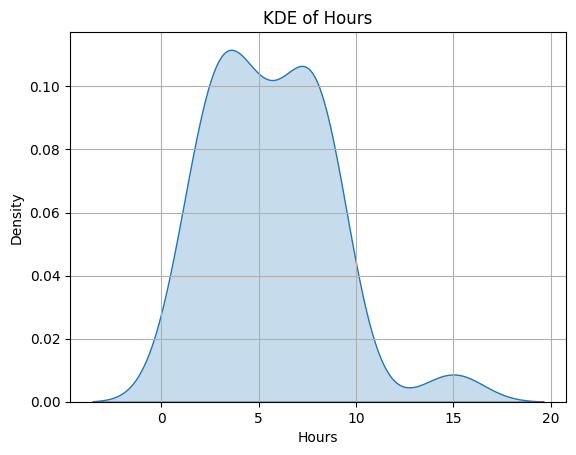

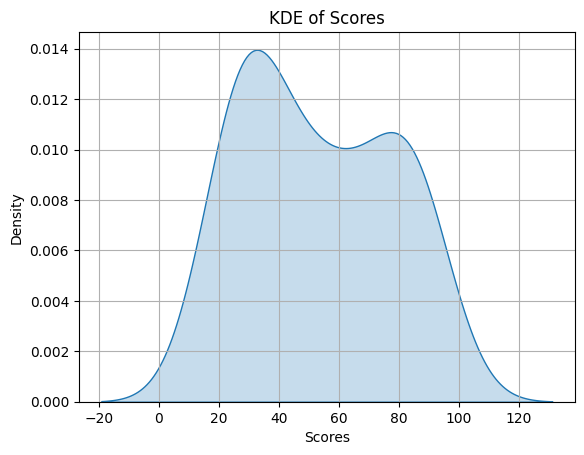

In [14]:
# KDE Plot: A KDE plot is a smooth curve that estimates the probability density function (PDF) of a continuous variable.
sns.kdeplot(df['Hours'], fill=True)  # fill=True: Fills the area under the KDE curve with color.'shade=True' in older seaborn versions
plt.title('KDE of Hours')
plt.xlabel('Hours')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# Obs: You can see there is an outliers at x=15

##############################
sns.kdeplot(df['Scores'], fill=True)  # fill=True: Fills the area under the KDE curve with color.'shade=True' in older seaborn versions
plt.title('KDE of Scores')
plt.xlabel('Scores')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# 4. Data preprocessing
## Lets check and deal with missing values

In [15]:
# Now lets get the count of missing values for each column/feature
missing_values = df.isnull().sum()
print(missing_values)

Hours     7
Scores    3
dtype: int64


In [16]:
# I want to see the missing values as percentage

# Count missing values per column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100  # Percentage of missing values

# Filter only columns with missing values
missing_df = pd.DataFrame({'Missing Values': missing_values,
                           'Percentage (%)': missing_percentage
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

# Display missing value counts
print("Missing Values Summary:")
print(missing_df)

Missing Values Summary:
        Missing Values  Percentage (%)
Hours                7       18.918919
Scores               3        8.108108


C:\Users\hi\AppData\Local\Temp\ipykernel_10712\1659466613.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Missing Values'], palette="viridis")


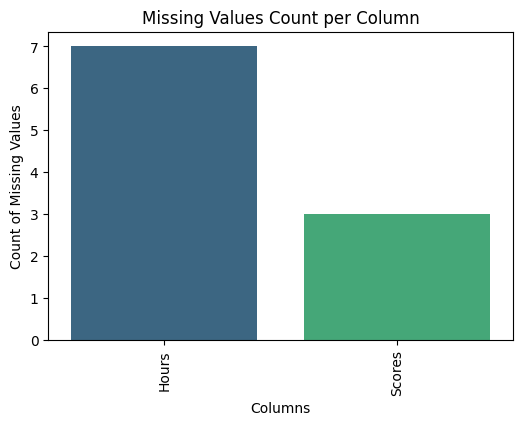

In [17]:
# Plot missing values as a bar chart
plt.figure(figsize=(6, 4))

sns.barplot(x=missing_df.index, y=missing_df['Missing Values'], palette="viridis")

plt.xticks(rotation=90)
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.title("Missing Values Count per Column")

plt.show()

In [18]:
# Here I am dropping missing values. There are other alternatives too.
print()
df = df.dropna()
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 0 to 36
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   27 non-null     float64
 1   Scores  27 non-null     float64
dtypes: float64(2)
memory usage: 648.0 bytes
None


In [19]:
# check missing values
missing_values = df.isnull().sum()
print(missing_values)

Hours     0
Scores    0
dtype: int64


## Now lets check and deal with duplicate values

In [20]:
# Finding and Handling Duplicate Records
duplicates = df.duplicated()
print("\nDuplicate Records:\n", df[duplicates])


Duplicate Records:
     Hours  Scores
36    7.8    86.0


In [21]:
# Removing duplicates
df = df.drop_duplicates()
print(f"\nDataFrame after removing duplicates:\n {df}")


DataFrame after removing duplicates:
     Hours  Scores
0     2.5    21.0
1     5.1    47.0
2     3.2    27.0
3     8.5    75.0
4     3.5    30.0
5     1.5    20.0
6     9.2    88.0
7     5.5    60.0
8     8.3    81.0
9     2.7    25.0
10    7.7    85.0
11    5.9    62.0
12    4.5    41.0
13    3.3    42.0
14    1.1    17.0
15    8.9    95.0
16    2.5    30.0
17    1.9    24.0
18    6.1    67.0
19    7.4    69.0
20   15.0    80.0
21    2.7    30.0
22    4.8    54.0
23    3.8    35.0
24    6.9    76.0
25    7.8    86.0


In [22]:
# Check if duplicates are dropped
duplicates = df.duplicated()
print("\nDuplicate Records:\n", df[duplicates])


Duplicate Records:
 Empty DataFrame
Columns: [Hours, Scores]
Index: []


In [23]:
# Lets deal with outliers: we drop them (or we could cap them)
import pandas as pd

# Step 1: Calculate Q1, Q3, and IQR
Q1 = df['Hours'].quantile(0.25)
Q3 = df['Hours'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Drop rows where 'Hours' is an outlier
df_no_outliers = df[(df['Hours'] >= lower_bound) & (df['Hours'] <= upper_bound)]

# Optional: reset index after filtering
df_no_outliers.reset_index(drop=True, inplace=True)

# Step 4: View the cleaned DataFrame
print(df_no_outliers)
df = df_no_outliers

    Hours  Scores
0     2.5    21.0
1     5.1    47.0
2     3.2    27.0
3     8.5    75.0
4     3.5    30.0
5     1.5    20.0
6     9.2    88.0
7     5.5    60.0
8     8.3    81.0
9     2.7    25.0
10    7.7    85.0
11    5.9    62.0
12    4.5    41.0
13    3.3    42.0
14    1.1    17.0
15    8.9    95.0
16    2.5    30.0
17    1.9    24.0
18    6.1    67.0
19    7.4    69.0
20    2.7    30.0
21    4.8    54.0
22    3.8    35.0
23    6.9    76.0
24    7.8    86.0


# Any correlation between features?
- Here there is only 1 feature, so this step is not as important
we see that there's a positive linear correlation between the Hours and Scores variables. How correlated are they? Anything above 0.8 is considered to be a strong positive correlation.

           Hours    Scores
Hours   1.000000  0.976191
Scores  0.976191  1.000000
##########################


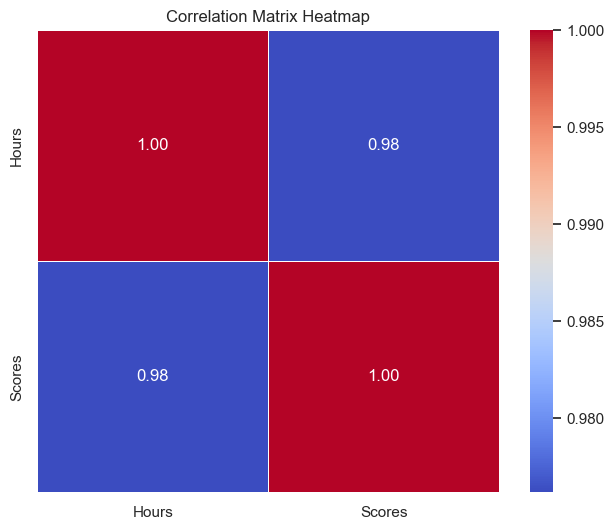

In [24]:

# yes, u can see strong correlation between scores are Hours
corr = df.corr()
print(corr) 
print("##########################")

# Set seaborn style
sns.set(style='whitegrid')

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)

plt.title("Correlation Matrix Heatmap")
plt.show()

In [25]:
print(df.describe())

           Hours     Scores
count  25.000000  25.000000
mean    5.012000  51.480000
std     2.525094  25.286887
min     1.100000  17.000000
25%     2.700000  30.000000
50%     4.800000  47.000000
75%     7.400000  75.000000
max     9.200000  95.000000


# 6. Data split
split dataset into train and test set. We would use training data to train the model

In [26]:
# Data split:
# Before splitting, seperate your data into feature X and response y
X = df[['Hours']] # This is the feature that would predict the y
y = df['Scores']

In [27]:
# I want to see how many records are in X
print(f"X shape:{X.shape}")
print("-----------------------------")
print(f"X:\n{X}")

X shape:(25, 1)
-----------------------------
X:
    Hours
0     2.5
1     5.1
2     3.2
3     8.5
4     3.5
5     1.5
6     9.2
7     5.5
8     8.3
9     2.7
10    7.7
11    5.9
12    4.5
13    3.3
14    1.1
15    8.9
16    2.5
17    1.9
18    6.1
19    7.4
20    2.7
21    4.8
22    3.8
23    6.9
24    7.8


In [28]:
# Now we split the dataset into training / testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42) # random state for reproducibility

In [29]:
# Lets see how many records are in training and testing dataset
print(f"X_train shape:{X_train.shape}")
print(f"y_train shape:{y_train.shape}")
print("************************************")
print(f"X_test shape:{X_test.shape}")
print(f"y_test shape:{y_test.shape}")


X_train shape:(20, 1)
y_train shape:(20,)
************************************
X_test shape:(5, 1)
y_test shape:(5,)


In [30]:
# I want to see the labels for training data
print(y_train)

9     25.0
13    42.0
1     47.0
22    35.0
5     20.0
2     27.0
12    41.0
15    95.0
3     75.0
4     30.0
20    30.0
17    24.0
21    54.0
18    67.0
24    86.0
7     60.0
10    85.0
14    17.0
19    69.0
6     88.0
Name: Scores, dtype: float64


In [31]:
# lets see the data for features space of training data
print(f"X_train:{X_train}")

X_train:    Hours
9     2.7
13    3.3
1     5.1
22    3.8
5     1.5
2     3.2
12    4.5
15    8.9
3     8.5
4     3.5
20    2.7
17    1.9
21    4.8
18    6.1
24    7.8
7     5.5
10    7.7
14    1.1
19    7.4
6     9.2


# 7. Train the model

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train) # This can take long time

LinearRegression()

In [33]:
# Lets make a prediction on score of a student who studies for hours=9.5,
# and check against the above plot
score = model.predict([[9.5]])
print(f"The score is {score}")

The score is [94.80663482]


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Analyze:
## The y intercept
To find the equation of line, 
$$
y = a_0 + a_1 x_1 
$$
we need to find  $a_0$ and $a_1$. We can get that from the above model.

In [34]:
#calculate
a0 = model.intercept_ # intercept
a1 = model.coef_[0] # # x-coefficient or slope

print(f"The intercept a0: {a0}")
print(f"The x-coeff a1: {a1}")

The intercept a0: 2.826892353899737
The x-coeff a1: 9.682078154455697


In [35]:
# Lets round them up
a0 = round(a0,4) # intercept
a1 = round(a1,4) # # x-coefficient or slope

print(f"The intercept: {a0}")
print(f"The x-coeff: {a1}")

The intercept: 2.8269
The x-coeff: 9.6821


This can quite literally be plugged in into our formula from before:
$$
y = 2.8269 + 9.6821 ∗ x_1
$$

**score = 2.8269 + 9.6821 ∗ hours**

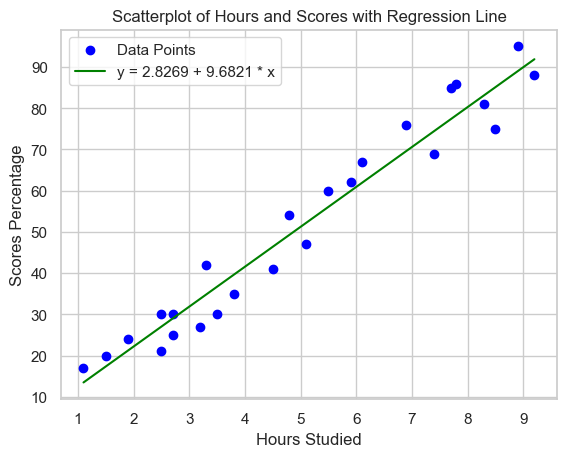

In [36]:
x = df['Hours']
y = df['Scores']

# Create the scatter plot
plt.scatter(x, y, label="Data Points", color="blue")

# Generate x values for the line
x_line = np.linspace(x.min(), x.max(), 100)  # Create a range of x values
y_line = a0 + a1 * x_line   # Compute corresponding y values using the equation

# Plot the regression line
plt.plot(x_line, y_line, color="green", label=f"y = {a0} + {a1} * x")

# Add labels and title
plt.xlabel("Hours Studied")
plt.ylabel("Scores Percentage")
plt.title("Scatterplot of Hours and Scores with Regression Line")

plt.legend() # Show legend

plt.show() # Display the plot


## Lets calculate score manually and also using the predict method

In [37]:
# Lets write a simple code to calculate score based on eqn: 
# score = a0 + a1 * hours
# score = 2.826 + 9.682 * hours
hours = 9.5
score = 2.826 + 9.682 * hours

print(score)

94.80499999999999


In [38]:
score = model.predict([[9.5]])
print(score)

[94.80663482]


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Both are same
So I wanted to show that this predicted value can also be obtained via the line intercept and slope value

# Predict values for larger dataset, say test

In [39]:
# Lets look at the test dataset
print(f"X_test:\n{X_test}")
print(f"y_test:\n{y_test}")

X_test:
    Hours
8     8.3
16    2.5
0     2.5
23    6.9
11    5.9
y_test:
8     81.0
16    30.0
0     21.0
23    76.0
11    62.0
Name: Scores, dtype: float64


In [40]:
# Lets make prediction on test data set
y_pred = model.predict(X_test)
print(y_pred)

[83.18814104 27.03208774 27.03208774 69.63323162 59.95115347]


In [41]:
# Lets prettify above and see the actual and prediction side-by-side for comparision

df_preds = pd.DataFrame({
    'hours': X_test.squeeze(),
    'actual_score': y_test.squeeze(),
    'predicted_score': y_pred.squeeze()})
print(df_preds)


    hours  actual_score  predicted_score
8     8.3          81.0        83.188141
16    2.5          30.0        27.032088
0     2.5          21.0        27.032088
23    6.9          76.0        69.633232
11    5.9          62.0        59.951153


In [47]:
# Now lets the see absolute difference between the actual and prediction and also the percentage difference.
df_preds['difference'] = (df_preds['actual_score'] - df_preds['predicted_score']).abs()

# Add the percentage difference column
df_preds['percentage_difference'] = (
    df_preds['difference'] / df_preds['actual_score']
) * 100

print(df_preds)

    hours  actual_score  predicted_score  difference  percentage_difference
8     8.3          81.0        83.188141    2.188141               2.701409
16    2.5          30.0        27.032088    2.967912               9.893041
0     2.5          21.0        27.032088    6.032088              28.724227
23    6.9          76.0        69.633232    6.366768               8.377327
11    5.9          62.0        59.951153    2.048847               3.304591


# 8. Model Performance Evaluation

##### Not much difference between actual and predicted score

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Compute R-squared (R²) value
r2 = r2_score(y_test, y_pred)

# Compute percentage-based errors
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Mean Absolute Percentage Error
relative_mae = (mae / np.mean(y_test)) * 100  # Relative MAE
relative_rmse = (rmse / np.mean(y_test)) * 100  # Relative RMSE
nrmse = (rmse / (y_test.max() - y_test.min())) * 100  # Normalized RMSE

# Print all results
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.4f}')  # closer to 1 is good
print("########################")

print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
print(f'Relative MAE: {relative_mae:.2f}%')
print(f'Relative RMSE: {relative_rmse:.2f}%')
print(f'Normalized RMSE (NRMSE): {nrmse:.2f}%')


Mean Absolute Error (MAE): 3.92
Mean Squared Error (MSE): 18.94
Root Mean Squared Error (RMSE): 4.35
R-squared (R²): 0.9678
########################
Mean Absolute Percentage Error (MAPE): 10.60%
Relative MAE: 7.26%
Relative RMSE: 8.06%
Normalized RMSE (NRMSE): 7.25%


### R-square value looking good

# 9. Hyperparameter tuning
No hyper parameters to tune.

# 10. Final Evaluation

# Save the model

In [44]:
# now lets save the model
import joblib

joblib.dump(model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

# Load the model later

In [45]:
# lets load the model
import joblib

loaded_model = joblib.load('linear_regression_model.pkl')

In [46]:
# make prediction
score = loaded_model.predict([[9.5]])
print(score)

[94.80663482]


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
